# Task 2: Predictive Modeling using Machine Learning

## Problem Statement
Predict whether a customer is a High Value Customer based on their purchasing behavior.

In [70]:
customer_data = df.groupby('CustomerID').agg({
    'InvoiceNo':'nunique',
    'Quantity':'sum',
    'Revenue':'sum'
}).reset_index()

customer_data.columns = [
    'CustomerID',
    'Total_Orders',
    'Total_Quantity',
    'Total_Revenue'
]

customer_data.head()

,CustomerID,Total_Orders,Total_Quantity,Total_Revenue
0,12346.0,2,0,0.00
1,12347.0,7,2458,4310.00
2,12348.0,4,2341,1797.24
3,12349.0,1,631,1757.55
4,12350.0,1,197,334.40


In [71]:
median_revenue = customer_data['Total_Revenue'].median()

customer_data['High_Value_Customer'] = (
    customer_data['Total_Revenue'] > median_revenue
).astype(int)

customer_data.head()

,CustomerID,Total_Orders,Total_Quantity,Total_Revenue,High_Value_Customer
0,12346.0,2,0,0.00,0
1,12347.0,7,2458,4310.00,1
2,12348.0,4,2341,1797.24,1
3,12349.0,1,631,1757.55,1
4,12350.0,1,197,334.40,0


In [72]:
customer_data['High_Value_Customer'].value_counts()

High_Value_Customer
0    2186
1    2186
Name: count, dtype: int64

In [73]:
X = customer_data[
    ['Total_Orders', 'Total_Quantity']
]

y = customer_data['High_Value_Customer']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [75]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [76]:
y_pred = model.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.872


In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       440
           1       0.86      0.88      0.87       435

    accuracy                           0.87       875
   macro avg       0.87      0.87      0.87       875
weighted avg       0.87      0.87      0.87       875



### Observation

The Random Forest Classifier achieved an overall accuracy of 87.2%.

The model demonstrated balanced performance across both customer classes, with precision, recall, and F1-scores close to 87%.

This indicates that the model can effectively distinguish between normal customers and high-value customers based on purchasing behavior.

The balanced evaluation metrics suggest that the model is reliable and not biased toward a particular class.

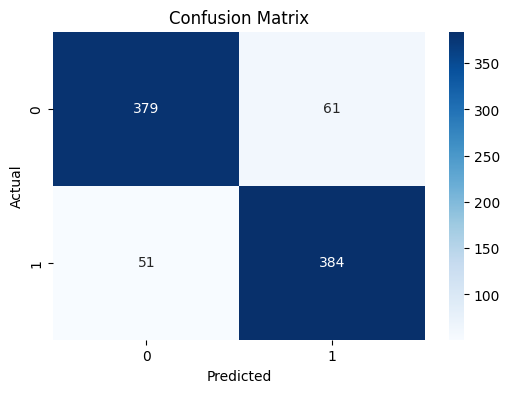

In [79]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Observation

The confusion matrix shows that the majority of customer classifications were predicted correctly.

Both high-value and normal customers were identified with a high degree of accuracy, indicating strong model performance.

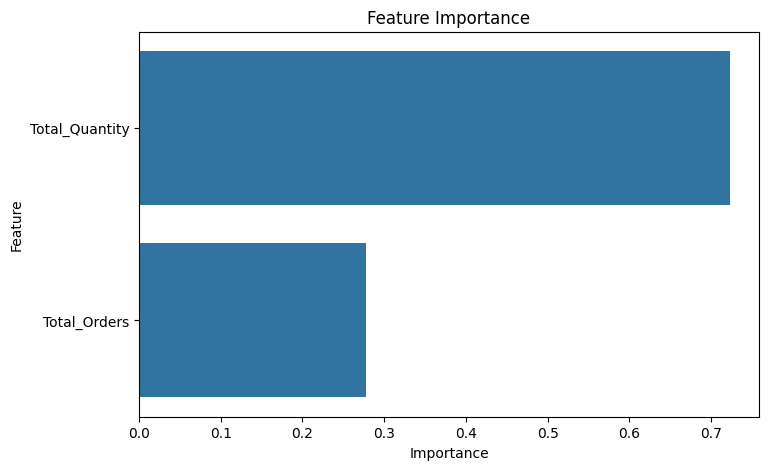

In [80]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

### Observation

Feature importance analysis revealed that customer purchasing behavior plays a significant role in determining customer value.

The most influential features contribute strongly to the model's ability to identify high-value customers.

# Results

| Metric | Value |
|----------|----------|
| Model Used | Random Forest Classifier |
| Accuracy | 87.2% |
| Precision | 87% |
| Recall | 87% |
| F1-Score | 87% |

The model successfully identified high-value customers using customer purchase patterns and achieved strong predictive performance.